Post-processing eccentricity posterior using [gw_eccentricity](https://github.com/vijayvarma392/gw_eccentricity)<br>
In this example, we use a parameter estimation result file from [Bilby](https://git.ligo.org/lscsoft/bilby)

In [6]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Path to PE result file

In [2]:
# result_file = "/Users/arif/Desktop/TEOB_chi0_9_ecc0_1_samples.hdf5"
# injection_file = "/Users/arif/Desktop/injection_params_TEOB_chi0_9_ecc0_1_samples.dat"
result_file = "/Users/arif/Desktop/TEOB_chi0_9_ecc0_3_samples.hdf5"
injection_file = "/Users/arif/Desktop/injection.dat"

# Postprocess the posterior file

For postprocessing Bilby result, we will use the derived class `PostProcessForBilby`

In [4]:
from gw_eccentricity.postprocess import PostProcessForBilby

## Create a datadict generator

In addition to the posterior result file, we need to provide a
`data_dict_generator` function which given a `params` dict, returns a data_dict
that will be used to measure eccentricity using
`gw_eccentricity.measure_eccentricity`

The intrinsic parameters (reference frequency, masses, spins, eccentricity and
mean anomaly) should match the parameters used to generate the waveforms when
using bilby

In this example, we use a posterior generated with `TEOBResumS-Dali` waveform
model. We will use `teob_data_dict_generator` from `teobresums_dali.py` as the `data_dict_generator`.

In [5]:
from teobresums_dali import teob_data_dict_generator

## Instantiate PostProcessForBilby class

Now we use the posterior result file and the `data_dict_generator` to instantiate an instance of  `PostProcessForBilby` class

In [7]:
# If  None, it works with the full posterior. We can work with only the relevant columns
parameter_columns = ["mass_1", "mass_2", "spin_1z", "spin_2z", "luminosity_distance", "minimum_frequency", "eccentricity", "mean_per_ano"]

egwBilby = PostProcessForBilby(result_file, data_dict_generator=teob_data_dict_generator,
                              data_dict_generator_extra_kwargs={"ode_tmax": 1, "backwards": "yes"},
                              injection_file=injection_file,
                              parameter_columns=parameter_columns)

22:49 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


## Looking at the original posteriors

In [8]:
egwBilby.posterior

,mass_1,mass_2,spin_1z,spin_2z,luminosity_distance,minimum_frequency,eccentricity,mean_per_ano
0,69.606326,48.389912,0.892924,0.840667,1863.475251,10.0,0.340209,2.603613
1,64.705539,52.509656,0.860734,0.884071,1459.715426,10.0,0.339408,3.756373
2,70.723160,46.216547,0.886695,0.756452,1867.117849,10.0,0.345114,2.279949
3,64.484123,52.938299,0.841869,0.868357,1974.297198,10.0,0.318437,0.244970
4,69.566824,45.800200,0.808252,0.812520,1853.087114,10.0,0.340370,0.608621
...,...,...,...,...,...,...,...,...
12723,59.868980,59.008436,0.893773,0.885188,1300.068425,10.0,0.308731,0.136035
12724,59.387763,59.054519,0.898561,0.881033,1228.920873,10.0,0.315228,0.294770
12725,59.715984,58.658780,0.883390,0.888504,1191.262543,10.0,0.312949,0.207168
12726,59.758918,59.013007,0.895735,0.890064,1309.544600,10.0,0.310986,0.184705


We can also load the injection in case we are doing an injection using model waveform.

In [29]:
injection = egwBilby.get_injection()

In [30]:
data_dict = egwBilby.get_injection_data_dict()

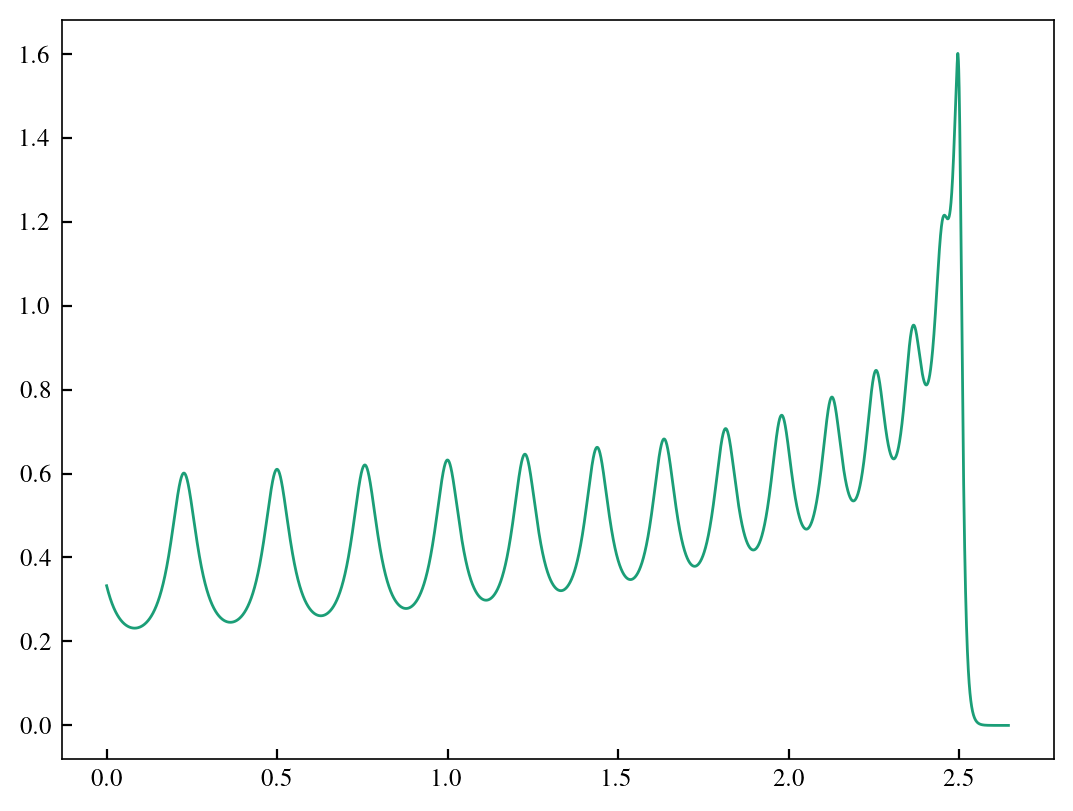

In [31]:
plt.plot(data_dict["t"], np.abs(data_dict["amplm"][(2, 2)]))

Finally plot the model posterior

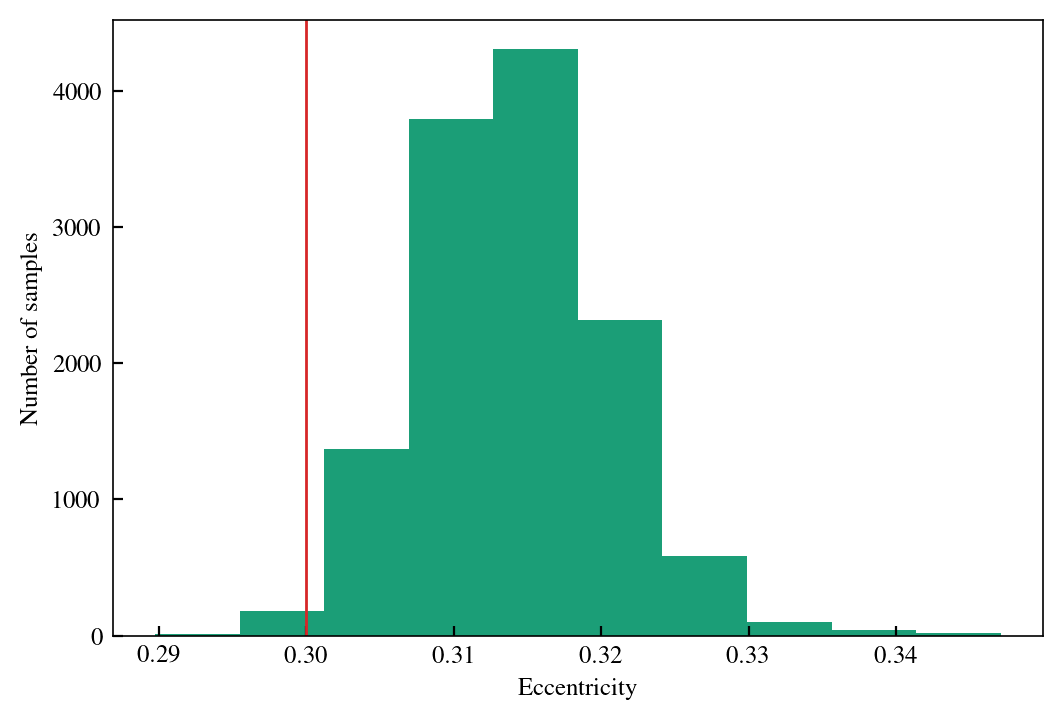

In [32]:
fig, ax = egwBilby.plot_eccentricity_posterior(**{"bins": 10})
ax.axvline(injection["eccentricity"], c="tab:red")

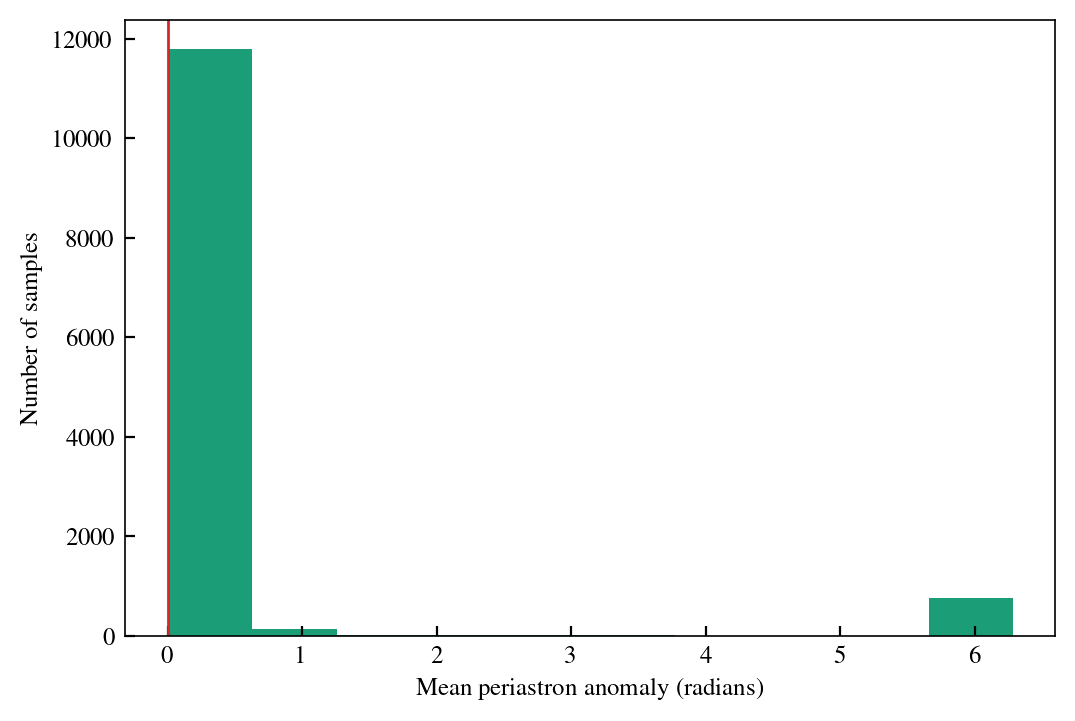

In [33]:
fig, ax = egwBilby.plot_mean_per_ano_posterior(**{"bins": 10})
ax.axvline(injection["mean_per_ano"], c="tab:red")

## Getting the allowed range of reference frequencies to use
Sometimes the chosen `fref`, the frequency where eccentricity and mean anomaly are to be measured could be outside the range where `egw` can be measured. Running the following code will give an idea of the `fref` bounds withing which majority of the samples can be post-processed.

This will also give an idea about how much backward evolving is required to get the orbit average frequency down to the desired `fref`.

In [14]:
import random

In [15]:
# we can use a subset of the samples to save time
samples = random.sample(range(0, len(egwBilby.posterior)), k=1000)

In [16]:
# some settings to use
method = "Amplitude"
gw_eccentricity_kwargs = {"extra_kwargs": {
    "omega_gw_extrema_interpolation_method": "spline"
}}
n_jobs = 6

In [17]:
fref_bounds_result = egwBilby.get_fref_bounds(
    samples=samples,
    method=method,
    n_jobs=n_jobs,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs)
print("Allowed range of reference frequencies are: ", fref_bounds_result.get_minmax_fref())

Getting fref bounds: 1000it [00:38, 26.23it/s]


Allowed range of reference frequencies are:  (np.float64(8.659504183900793), np.float64(29.446001427623116))


The range of allowed reference frequencies comes from the samples where eccentricity measurement is successfull. We can get a summary of how many samples were successfully processed.

In [18]:
fref_bounds_result.get_summary()["success_percentage"]

100.0

We can also view the full result as a DataFrame

In [19]:
fref_bounds_result.to_dataframe()

,sample_index,status,fref_min,fref_max,error_message
0,10375,success,8.547024,30.322423,None
1,1737,success,8.559615,30.159936,None
2,5116,success,8.526787,30.648179,None
3,5034,success,8.514442,30.744616,None
4,9577,success,8.457261,31.210128,None
...,...,...,...,...,...
995,4353,success,8.400741,31.278250,None
996,6450,success,8.475120,30.843780,None
997,7260,success,8.517238,30.520582,None
998,2851,success,8.581565,30.114639,None


## Postprocessing

We can postprocess a subset of the smaples or all the samples using the following method

In [20]:
import time

In [21]:
fref = 10
t_start = time.perf_counter()
samples = random.sample(range(0, len(egwBilby.posterior)), k=1000)
egwBilby.postprocess(fref=fref, samples=samples,
                      method=method,
                      gw_eccentricity_kwargs=gw_eccentricity_kwargs,
                      n_jobs=n_jobs)
t_stop = time.perf_counter()

Postprocessing samples: 1000it [00:35, 28.50it/s]


In [22]:
print(f"Took {t_stop - t_start} seconds for {len(samples)} samples on {n_jobs} cores.")

Took 35.85324933299853 seconds for 1000 samples on 6 cores.


### View the postprocessing results

In [23]:
egwBilby.postprocess_result.results[:5]

[PostProcessResult(sample_index=11826, status='success', egw=np.float64(0.32276409732770095), lgw=np.float64(2.6396166400796215), error_message=None),
 PostProcessResult(sample_index=9866, status='success', egw=np.float64(0.3274935314442552), lgw=np.float64(2.5420101521609), error_message=None),
 PostProcessResult(sample_index=3519, status='success', egw=np.float64(0.3282881370595051), lgw=np.float64(2.678469967074623), error_message=None),
 PostProcessResult(sample_index=10459, status='success', egw=np.float64(0.3144315259925442), lgw=np.float64(2.343001726310897), error_message=None),
 PostProcessResult(sample_index=10315, status='success', egw=np.float64(0.3146596524944748), lgw=np.float64(2.2708324727560836), error_message=None)]

View as a DataFrame

In [24]:
egwBilby.postprocess_result.to_dataframe()

,sample_index,status,egw,lgw,error_message
0,11826,success,0.322764,2.639617,None
1,9866,success,0.327494,2.542010,None
2,3519,success,0.328288,2.678470,None
3,10459,success,0.314432,2.343002,None
4,10315,success,0.314660,2.270832,None
...,...,...,...,...,...
995,3733,success,0.314794,2.363231,None
996,8414,success,0.323999,2.444416,None
997,5008,success,0.312867,2.252876,None
998,664,success,0.328281,2.842972,None


Get a summary

In [25]:
egwBilby.postprocess_result.get_summary()["success_percentage"]

100.0

Measure eccentricity of the injection

In [26]:
egw_inj, mean_ano_inj = egwBilby.get_injection_eccentricity(
    fref=fref,
    method=method,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs,
)

Plot the `egw` posterior

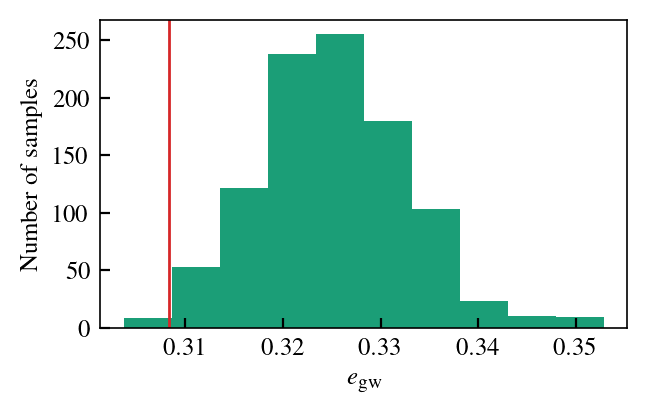

In [27]:
fig, ax = egwBilby.plot_egw_posterior(usetex=True, style="APS")
ax.axvline(egw_inj, c="tab:red")

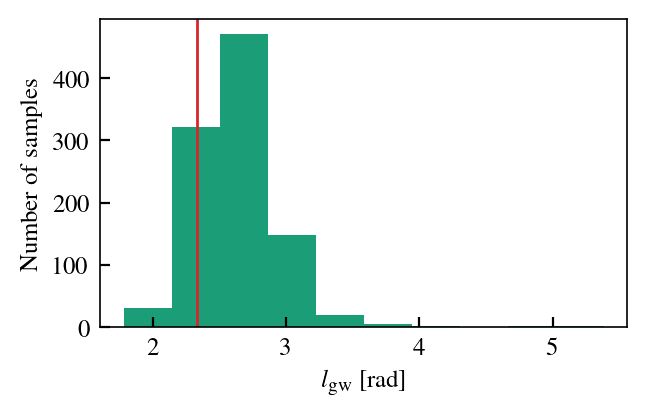

In [28]:
fig, ax = egwBilby.plot_lgw_posterior(usetex=True, style="APS")
ax.axvline(mean_ano_inj, c="tab:red")